In [1]:
import pandas as pd
import numpy as np 
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB

## Db Import and Overview

In [2]:
df = pd.read_csv('IMDB Dataset.csv')
df = df[['review','sentiment']]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
df.shape

(50000, 2)

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

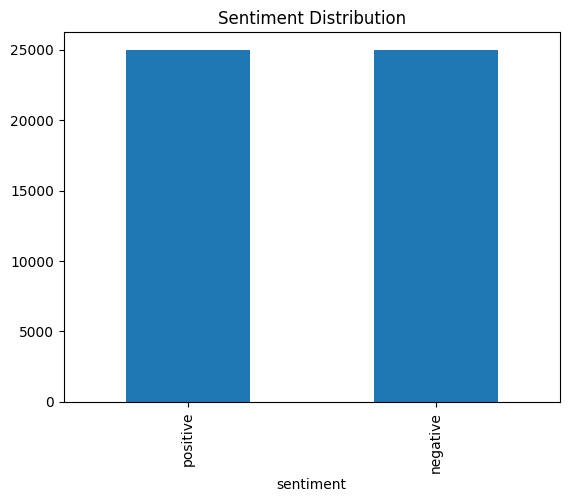

In [7]:
plt.figure()
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.show()

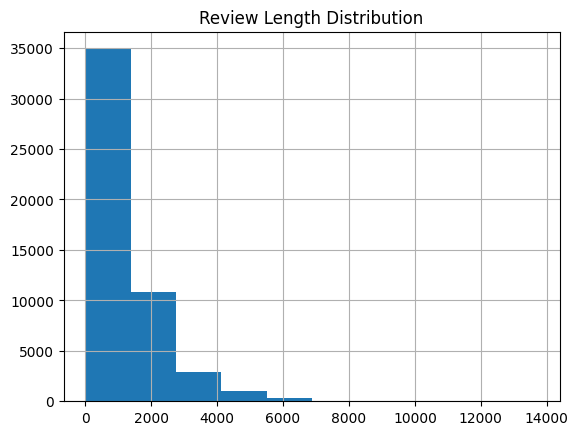

In [8]:
df['length'] = df['review'].apply(len)
plt.figure()
df['length'].hist()
plt.title('Review Length Distribution')
plt.show()

In [9]:
df

,review,sentiment,length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317
...,...,...,...
49995,I thought this movie did a down right good job...,positive,1008
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,642
49997,I am a Catholic taught in parochial elementary...,negative,1280
49998,I'm going to have to disagree with the previou...,negative,1234


## Text Preprocessing

In [10]:
def clean_text(text):
 text = re.sub(r"<.*?>","",text)
 text = re.sub(r"[^a-zA-Z ]","",text)
 return text.lower() # Remove punctuations and  lowercasing
def handle_negation(text):
 return re.sub(r"not\s+(\w+)", r"not_\1", text) # Handle negations

df['review'] = df['review'].apply(clean_text).apply(handle_negation) 

## Train-Test Split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(df['review'],df['sentiment'],test_size=0.2,random_state=42)

## Feature Extraction

In [12]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,3)
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (40000, 10000)


In [13]:
bow = CountVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,3)
)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print("BoW shape:", X_train_bow.shape)

BoW shape: (40000, 10000)


## TFIDF + Linear SVM Model

Accuracy:-  0.8863


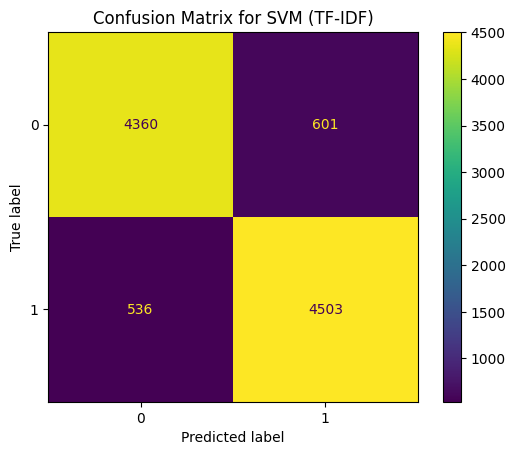

In [14]:
model1 = LinearSVC()
model1.fit(X_train_tfidf,y_train)

pred1 = model1.predict(X_test_tfidf)
print('Accuracy:- ', accuracy_score(y_test,pred1))

cm1 = confusion_matrix(y_test,pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot()
plt.title("Confusion Matrix for SVM (TF-IDF)")
plt.show()

## BoW + Linear SVM Model

Accuracy:-  0.8468


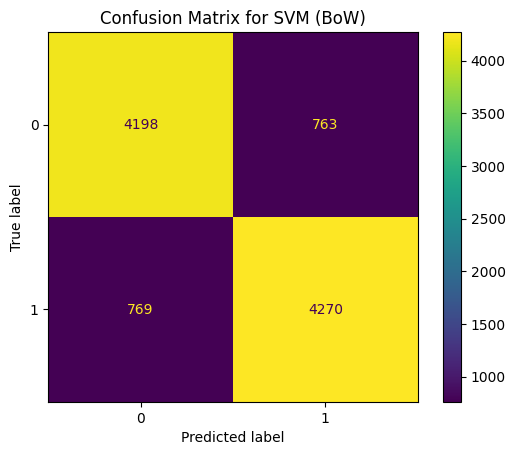

In [15]:
model2 = LinearSVC()
model2.fit(X_train_bow,y_train)
pred2 = model2.predict(X_test_bow)
print('Accuracy:- ',accuracy_score(y_test,pred2))

cm2 = confusion_matrix(y_test,pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot()
plt.title("Confusion Matrix for SVM (BoW)")
plt.show()

## TFIDF + Naive Bayes Model

Accuracy: 0.8591


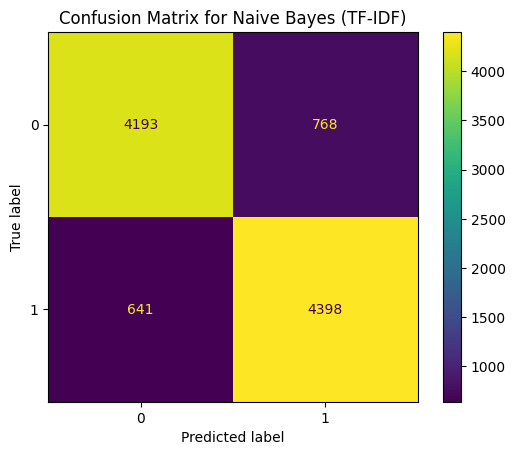

In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy)

cm1 = confusion_matrix(y_test,y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.title("Confusion Matrix for Naive Bayes (TF-IDF)")
plt.show()


## BoW + Naive Bayes Model

Accuracy: 0.8591


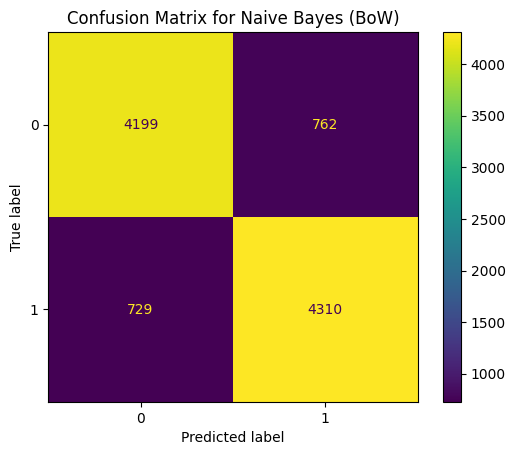

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
y_pred_nb1 = nb_model.predict(X_test_bow)
accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy)

cm1 = confusion_matrix(y_test,y_pred_nb1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.title("Confusion Matrix for Naive Bayes (BoW)")
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

y_pred_nb = nb_model.predict(X_test_tfidf)
y_pred_svm = model1.predict(X_test_tfidf)

def calculate_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    TN, FP, FN, TP = cm.ravel()

    accuracy = round(accuracy_score(y_true, y_pred),2)
    precision = round(precision_score(y_true, y_pred, pos_label='positive'),2)
    recall = round(recall_score(y_true, y_pred, pos_label='positive'),2)
    f1 = round(f1_score(y_true, y_pred, pos_label='positive'),2)
    sensitivity = round(TP / (TP + FN),2)
    specificity = round(TN / (TN + FP),2)
    fpr = round(FP / (FP + TN),2)
    fnr = round(FN / (FN + TP),2)
    npv = round(TN / (TN + FN),2)
    fdr = round(FP / (FP + TP),2)
    mcc = round(((TP * TN) - (FP * FN)) / np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)),2)
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "FPR": fpr,
        "FNR": fnr,
        "NPV": npv,
        "FDR": fdr,
        "MCC": mcc
    }

nb_metrics = calculate_metrics(y_test, y_pred_nb)
svm_metrics = calculate_metrics(y_test, y_pred_svm)

comparison_df = pd.DataFrame({
    "Naive Bayes": nb_metrics,
    "SVM": svm_metrics
})

comparison_df

,Naive Bayes,SVM
Accuracy,0.85,0.89
Precision,0.83,0.88
Recall,0.88,0.89
F1-Score,0.86,0.89
Sensitivity,0.88,0.89
Specificity,0.82,0.88
FPR,0.18,0.12
FNR,0.12,0.11
NPV,0.87,0.89
FDR,0.17,0.12


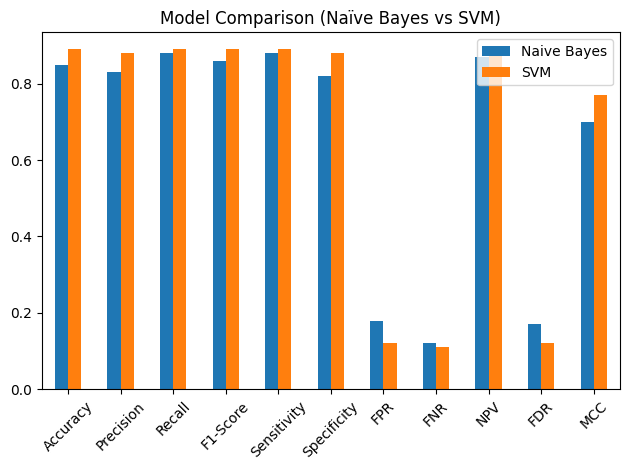

In [19]:
comparison_df.plot(kind='bar')
plt.title("Model Comparison (Naïve Bayes vs SVM)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:


def predict_sentiment(review):
    
    review = clean_text(review)
    review = handle_negation(review)

    review_tfidf = tfidf.transform([review])

    prediction = model1.predict(review_tfidf)[0]

    return prediction


user_review = input("Enter a movie review: ")

result = predict_sentiment(user_review)

print("\nReview:", user_review)
print("Predicted Sentiment:", result.upper())


Review: i loved the movie
Predicted Sentiment: POSITIVE


In [21]:

emotion_words = {

    "joy": [
        "happy", "happiness", "joy", "joyful", "love", "loved",
        "lovely", "amazing", "awesome", "excellent", "fantastic",
        "wonderful", "brilliant", "great", "good", "fun",
        "enjoy", "enjoyed", "enjoyable", "excited", "exciting",
        "perfect", "beautiful", "best", "pleasure"
    ],

    "anger": [
        "angry", "anger", "hate", "hated", "horrible", "terrible",
        "furious", "annoyed", "annoying", "rage", "rude",
        "worst", "awful", "disgusting", "irritating", "irritated"
    ],

    "sadness": [
        "sad", "sadness", "unhappy", "depressed", "cry",
        "crying", "tears", "lonely", "loneliness", "disappointed",
        "disappointing", "disappointment", "pain", "painful",
        "tragic", "heartbroken", "sorry"
    ],

    "fear": [
        "fear", "fearful", "scared", "scary", "frightened",
        "terrified", "terror", "horror", "horrifying",
        "danger", "dangerous", "threat", "threatening",
        "panic", "panicked"
    ],

    "surprise": [
        "surprised", "surprise", "shocked", "shock",
        "unexpected", "unbelievable", "suddenly",
        "astonishing", "astonished", "wow", "incredible"
    ]
}


def detect_emotions(review):

    # Convert review into lowercase words
    words = re.findall(r'\b[a-zA-Z]+\b', review.lower())

    emotion_scores = {}

    # Count emotion-related words
    for emotion, keywords in emotion_words.items():

        count = 0

        for word in words:
            if word in keywords:
                count += 1

        emotion_scores[emotion] = count

    # Total emotion words
    total = sum(emotion_scores.values())

    # If no emotion words are found
    if total == 0:
        emotion_percentages = {
            emotion: 0 for emotion in emotion_scores
        }

        emotion_percentages["neutral"] = 100

    else:

        emotion_percentages = {}

        for emotion, score in emotion_scores.items():

            percentage = (score / total) * 100

            emotion_percentages[emotion] = percentage

        emotion_percentages["neutral"] = 0

    # Find dominant emotion
    dominant_emotion = max(
        emotion_percentages,
        key=emotion_percentages.get
    )

    return emotion_percentages, dominant_emotion




def complete_nlp_analysis(review):


    cleaned_review = clean_text(review)
    cleaned_review = handle_negation(cleaned_review)

    review_tfidf = tfidf.transform([cleaned_review])

    sentiment = model1.predict(review_tfidf)[0]

    # SVM confidence
    decision_score = model1.decision_function(review_tfidf)[0]

    confidence = 1 / (1 + np.exp(-abs(decision_score)))
    confidence = confidence * 100

    emotion_percentages, dominant_emotion = detect_emotions(review)

    print("\n" + "=" * 65)
    print("             NLP SENTIMENT + EMOTION ANALYSIS")
    print("=" * 65)

    print("\nReview:")
    print(review)

    print("\nSentiment:")
    print(sentiment.upper())

    print("\nConfidence:")
    print(f"{confidence:.2f}%")

    print("\nEmotion Analysis:")

    # Display emotions
    emotion_icons = {
        "joy": "😊",
        "anger": "😡",
        "sadness": "😢",
        "fear": "😨",
        "surprise": "😲",
        "neutral": "😐"
    }

    for emotion, percentage in emotion_percentages.items():

        icon = emotion_icons.get(emotion, "")

        print(
            f"{icon} {emotion.capitalize():10s}: "
            f"{percentage:.2f}%"
        )

    print("\nDominant Emotion:")
    print(
        emotion_icons.get(dominant_emotion, ""),
        dominant_emotion.upper()
    )

    print("\n" + "=" * 65)


user_review = input("Enter a movie review: ")

complete_nlp_analysis(user_review)


             NLP SENTIMENT + EMOTION ANALYSIS

Review:
i loved the movie

Sentiment:
POSITIVE

Confidence:
90.43%

Emotion Analysis:
😊 Joy       : 100.00%
😡 Anger     : 0.00%
😢 Sadness   : 0.00%
😨 Fear      : 0.00%
😲 Surprise  : 0.00%
😐 Neutral   : 0.00%

Dominant Emotion:
😊 JOY



In [22]:
import joblib

# Save the trained LinearSVC model and the fitted TF-IDF vectorizer
joblib.dump(model1, 'svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Files saved successfully!")

Files saved successfully!


## Explanation
- The Naive Bayes classifier achieved good accuracy because it uses probability of words for classification.
- TF-IDF performed better than BoW because it gives more importance to meaningful words.
- Linear SVM performed better than Naive Bayes because it creates better decision boundaries.
- Some reviews were misclassified due to:
  1. Negation (e.g., "not good")
  2. Mixed sentiments in a sentence
  3. Lack of contextual understanding
- Naive Bayes is fast and simple but slightly less accurate.
- TF-IDF + SVM gives the best performance in this project.